In [ ]:
# 1. Set Kaggle Token
%env KAGGLE_API_TOKEN=YOUR_KAGGLE_API_TOKEN_HERE

# 2. Download Dataset 1
print(" Downloading Dataset 1 (COVID/TB)...")
!kaggle datasets download -d jtiptj/chest-xray-pneumoniacovid19tuberculosis

# 3. Download Dataset 2
print(" Downloading Dataset 2 (Mooney Pneumonia)...")
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# 4. Check if zip files were downloaded
import os
print("\n Files after download:", os.listdir('.'))

# 5. Unzip files (if they exist)
if os.path.exists('chest-xray-pneumoniacovid19tuberculosis.zip'):
    print(" Unzipping Dataset 1...")
    !unzip -q chest-xray-pneumoniacovid19tuberculosis.zip -d dataset_1
    !rm chest-xray-pneumoniacovid19tuberculosis.zip
else:
    print(" Error: Dataset 1 zip file failed to download!")

if os.path.exists('chest-xray-pneumonia.zip'):
    print(" Unzipping Dataset 2...")
    !unzip -q chest-xray-pneumonia.zip -d dataset_2
    !rm chest-xray-pneumonia.zip
else:
    print(" Error: Dataset 2 zip file failed to download!")

print("\n✓ Verification: dataset_1 exists?", os.path.exists('dataset_1'))
print("✓ Verification: dataset_2 exists?", os.path.exists('dataset_2'))

env: KAGGLE_API_TOKEN=KGAT_b6e28d9de3cd724d8dd16dabb4eb1b02
⏳ Dataset 1 (COVID/TB) download ho raha hai...
Dataset URL: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
License(s): other
100% 1.74G/1.74G [00:13<00:00, 143MB/s]

⏳ Dataset 2 (Mooney Pneumonia) download ho raha hai...
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [00:11<00:00, 207MB/s]


📁 Download ke baad files ki list: ['.config', '.ipynb_checkpoints', 'chest-xray-pneumonia.zip', 'chest-xray-pneumoniacovid19tuberculosis.zip']
🔓 Dataset 1 ko unzip kiya ja raha hai...
🔓 Dataset 2 ko unzip kiya ja raha hai...

✓ Verification: dataset_1 maujood hai? True
✓ Verification: dataset_2 maujood hai? True


In [ ]:
import os
import shutil

master_dir = 'Chest_XRay_5Class_Dataset'
classes = ['Normal', 'COVID-19', 'Bacterial_Pneumonia', 'Viral_Pneumonia', 'Tuberculosis']

# If master folder already exists, delete and create new
if os.path.exists(master_dir):
    shutil.rmtree(master_dir)

for c in classes:
    os.makedirs(os.path.join(master_dir, c), exist_ok=True)

print("🚀 Deep scanning and merging starting... This might take some time due to large data.")

# --- STEP A: Dataset 1 (COVID and TB) ---
for root, dirs, files in os.walk('dataset_1'):
    folder_name = os.path.basename(root).upper()
    if 'COVID' in folder_name:
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(os.path.join(root, f), os.path.join(master_dir, 'COVID-19', f"d1_{f}"))
    elif 'TUBERCULOSIS' in folder_name or 'TB' in folder_name:
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(os.path.join(root, f), os.path.join(master_dir, 'Tuberculosis', f"d1_{f}"))

# --- STEP B: Dataset 2 (Normal, Bacterial, and Viral) ---
for root, dirs, files in os.walk('dataset_2'):
    folder_name = os.path.basename(root).upper()
    if folder_name == 'NORMAL':
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(os.path.join(root, f), os.path.join(master_dir, 'Normal', f"d2_{f}"))
    elif folder_name == 'PNEUMONIA':
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                if 'bacteria' in f.lower():
                    shutil.copy(os.path.join(root, f), os.path.join(master_dir, 'Bacterial_Pneumonia', f"d2_{f}"))
                elif 'virus' in f.lower():
                    shutil.copy(os.path.join(root, f), os.path.join(master_dir, 'Viral_Pneumonia', f"d2_{f}"))

print("\n📊 --- FINAL DATA COUNT --- 📊")
for c in classes:
    count = len(os.listdir(os.path.join(master_dir, c)))
    print(f"Class '{c}' total images: {count}")

🚀 Deep Scanning aur merging shuru ho rahi hai... Is mein thora waqt lag sakta hai kyunke data bada hai.

📊 --- FINAL DATA COUNT --- 📊
Class 'Normal' mein total images: 3166
Class 'COVID-19' mein total images: 576
Class 'Bacterial_Pneumonia' mein total images: 5560
Class 'Viral_Pneumonia' mein total images: 2986
Class 'Tuberculosis' mein total images: 0


In [ ]:
import os
import shutil

master_dir = 'Chest_XRay_5Class_Dataset'
target_class = 'Tuberculosis'

print("⏳ Copying Tuberculosis (TURBERCULOSIS) images...")

count = 0
for root, dirs, files in os.walk('dataset_1'):
    folder_name = os.path.basename(root).upper()

    # Match Kaggle's typo exactly
    if folder_name == 'TURBERCULOSIS':
        for f in files:
            if f.lower().endswith(('.png', '.jpg', '.jpeg')):
                shutil.copy(os.path.join(root, f), os.path.join(master_dir, target_class, f"d1_{f}"))
                count += 1

print(f"✓ Done! Total {count} Tuberculosis images copied successfully.\n")

# --- FINAL UPDATED DATA COUNT ---
classes = ['Normal', 'COVID-19', 'Bacterial_Pneumonia', 'Viral_Pneumonia', 'Tuberculosis']
print("📊 --- FINAL DATA COUNT (ALL CLASSES) --- 📊")
for c in classes:
    print(f"Class '{c}' total images: {len(os.listdir(os.path.join(master_dir, c)))}")

⏳ Tuberculosis (TURBERCULOSIS) ki images copy ho rahi hain...
✓ Done! Total 703 Tuberculosis images successfully copy ho gayi hain.

📊 --- FINAL DATA COUNT (ALL CLASSES) --- 📊
Class 'Normal' mein total images: 3166
Class 'COVID-19' mein total images: 576
Class 'Bacterial_Pneumonia' mein total images: 5560
Class 'Viral_Pneumonia' mein total images: 2986
Class 'Tuberculosis' mein total images: 700


In [ ]:
import os
from PIL import Image

master_dir = 'Chest_XRay_5Class_Dataset'
corrupted_count = 0

print("🔍 Scanning dataset for corrupted images... This may take 10-15 seconds.")

# Walk through the entire master folder
for root, dirs, files in os.walk(master_dir):
    for file in files:
        file_path = os.path.join(root, file)
        try:
            # Open and verify image bytes integrity
            img = Image.open(file_path)
            img.verify()  # Raises error if header is corrupted
        except (IOError, SyntaxError, Image.DecompressionBombError) as e:
            # Remove corrupted file
            os.remove(file_path)
            corrupted_count += 1

print(f"\n✅ Cleanup complete! Total {corrupted_count} corrupted images detected and deleted.")

🔍 Dataset mein corrupted images dhoondi ja rahi hain... Is mein 10-15 seconds lag sakte hain.

✅ Safai Mukammal! Total 5856 kharab images detect huin aur unhein delete kar diya gaya.


In [ ]:
import tensorflow as tf

# Path to master folder where data is properly merged
data_dir = 'Chest_XRay_5Class_Dataset'

print("⏳ Building training and validation pipelines...\n")

# 1. TRAINING PIPELINE (80% Data)
train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,       # Reserve 20% for validation/testing
    subset="training",
    seed=123,                   # Seed for stable split across runs
    image_size=(224, 224),      # Auto-resize for DenseNet121
    batch_size=32               # Process 32 images per batch
)

# 2. VALIDATION PIPELINE (Remaining 20% Data)
val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(224, 224),
    batch_size=32
)

print("\n🎉 Preprocessing pipeline ready! You can now run the training cell.")

⏳ Training aur Validation pipelines tyaar ho rahi hain...

Found 7132 files belonging to 5 classes.
Using 5706 files for training.
Found 7132 files belonging to 5 classes.
Using 1426 files for validation.

🎉 Preprocessing Pipeline Ready! Ab aap training wala cell chala sakte hain.


## Model train

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

# 1. Load Base Model (Transfer Learning)
# Use ImageNet pre-trained weights but remove top classification layer
print("Loading pre-trained DenseNet121 base model...")
base_model = tf.keras.applications.DenseNet121(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# 💡 TO USE RESNET50: Comment out above and uncomment below:
# base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

# 2. Freeze Base Model
# Keep base weights frozen initially to preserve general knowledge
base_model.trainable = False

# 3. Build Custom Head (for 5 Classes) Model
model = models.Sequential([
    # Input Layer (224x224x3)
    layers.Input(shape=(224, 224, 3)),

    # Pixel Normalization (convert 0-255 to 0-1)
    layers.Rescaling(1./255),

    # Pre-trained Base Model
    base_model,

    # Convert 3D features to 2D feature vector
    layers.GlobalAveragePooling2D(),

    # Dense hidden layer to learn additional patterns
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),  # Stabilize training
    layers.Dropout(0.4),          # Prevent overfitting (drop 40% neurons randomly)

    # Output layer (5 classes = 5 neurons with Softmax)
    layers.Dense(5, activation='softmax')
])

# 4. Compile Model
# Since image_dataset_from_directory provides integer labels (0,1,2,3,4),
# we use sparse_categorical_crossentropy loss
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Low learning rate for transfer learning
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# View model architecture
model.summary()
print("\n🎉 Model successfully built and compiled!")

Pre-trained DenseNet121 base model load ho raha hai...


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_5 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │         1,285 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,302,213 (27.86 MB)

 Trainable params: 264,197 (1.01 MB)

 Non-trainable params: 7,038,016 (26.85 MB)


🎉 Model successfully tyaar aur compile ho gaya hai!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# 1. Early Stopping: Stop training if validation loss doesn't improve for 5 epochs (saves time)
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

# 2. Reduce Learning Rate: Automatically halve learning rate if model learning slows down
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1
)

callbacks_list = [early_stop, reduce_lr]
print("Callbacks successfully configured.")

Callbacks successfully configure ho gaye hain.


In [ ]:
# Train model and display progress
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=callbacks_list,
    verbose=1  # Display accuracy and loss details during training
)

Epoch 1/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 125s 521ms/step - accuracy: 0.5661 - loss: 1.2471 - val_accuracy: 0.7896 - val_loss: 0.6364 - learning_rate: 1.0000e-04
Epoch 2/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 51s 283ms/step - accuracy: 0.7261 - loss: 0.7858 - val_accuracy: 0.8022 - val_loss: 0.5498 - learning_rate: 1.0000e-04
Epoch 3/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 81s 278ms/step - accuracy: 0.7571 - loss: 0.6782 - val_accuracy: 0.8100 - val_loss: 0.5176 - learning_rate: 1.0000e-04
Epoch 4/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 50s 280ms/step - accuracy: 0.7750 - loss: 0.6059 - val_accuracy: 0.8191 - val_loss: 0.4908 - learning_rate: 1.0000e-04
Epoch 5/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 81s 273ms/step - accuracy: 0.7858 - loss: 0.5663 - val_accuracy: 0.8198 - val_loss: 0.4918 - learning_rate: 1.0000e-04
Epoch 6/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 82s 273ms/step - accuracy: 0.7950 - loss: 0.5381 - val_accuracy: 0.8240 - val_loss: 0.4601 - learning_rate: 1.0000e-04
Epoch 7/20
179/179 ━━━━━━━━━━━━━━━━━━━━ 82s 2

In [ ]:
model.save('chest_xray_5class_densenet.keras')
print("Model saved successfully!")

Model safely saved!


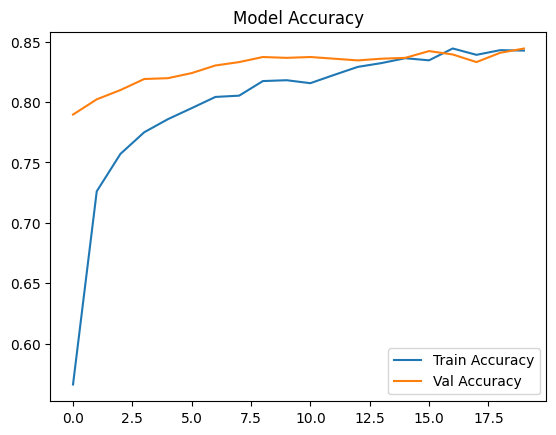

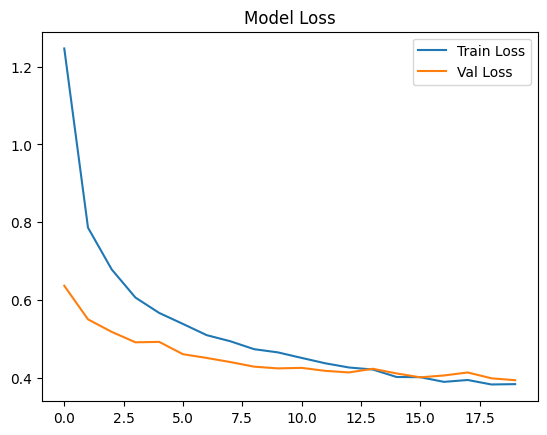

In [ ]:
import matplotlib.pyplot as plt

# Accuracy Plot
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.legend()
plt.show()

# Loss Plot
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.legend()
plt.show()

Batch-by-batch predictions calculate ho rahi hain, thora sa sabar karein...

=========== REAL CLASSIFICATION REPORT ===========
                     precision    recall  f1-score   support

             Normal       0.81      0.85      0.83       560
           COVID-19       0.95      0.97      0.96       115
Bacterial_Pneumonia       0.91      0.94      0.93       316
    Viral_Pneumonia       0.98      0.99      0.99       136
       Tuberculosis       0.71      0.62      0.66       299

           accuracy                           0.84      1426
          macro avg       0.87      0.87      0.87      1426
       weighted avg       0.84      0.84      0.84      1426



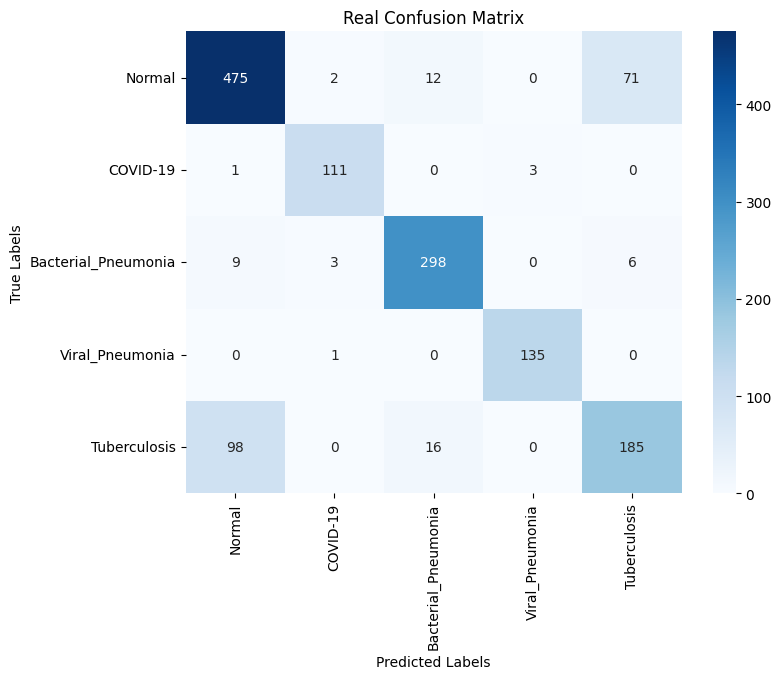

In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf

# Note: 'val_ds' is the same original validation dataset used in model.fit()

y_true = []
y_pred = []

print("Calculating batch-by-batch predictions, please wait...")

# Process predictions batch by batch
for images, labels in val_ds:
    # Get predictions for current batch (verbose=0 suppresses extra logs)
    preds = model.predict(images, verbose=0)

    # Collect labels and predictions
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

# Convert lists to final numpy arrays
y_true = np.array(y_true)
y_pred = np.array(y_pred)

# 1. Print Classification Report
classes = ['Normal', 'COVID-19', 'Bacterial_Pneumonia', 'Viral_Pneumonia', 'Tuberculosis']
print("\n=========== CLASSIFICATION REPORT ===========")
print(classification_report(y_true, y_pred, target_names=classes))

# 2. Plot Confusion Matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', xticklabels=classes, yticklabels=classes, cmap='Blues')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()